# Test Environment

Checks the gymnasium environment and verifies IMU orientation. Press `shift+enter` to run each cell.

In [2]:
# Import standard libraries
import math
from pathlib import Path
import sys
import time

# Third-party libraries
from gymnasium.utils.env_checker import check_env
import matplotlib.pyplot as plt
import mujoco
import numpy as np

/config/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-mtcdvz4i because there was an issue with the default path (/config/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
# Import the custom environment
from balance_bot_env_dr import BalanceBotEnv

In [4]:
# Settings
MJCF_PATH = Path("../../mechanical/bala-c-plus-simplified/bala-c-plus-simplified.xml")
SEED = 42

## Check that the environment loads

In [7]:
# Initialize environment
env = BalanceBotEnv(mjcf_path=MJCF_PATH, render_mode="human")

# Print observation and action spaces
print(env.observation_space)
print(env.action_space)

Box([ -3.1415927 -20.       ], [ 3.1415927 20.       ], (2,), float32)
Box(-1.0, 1.0, (2,), float32)


In [8]:
# Use gymnasium's built-in environment checker
# Ignore the warning, error is bad
check_env(env)
env.close()

## Run simulation with dummy policy

In [9]:
# Initialize environment
env = BalanceBotEnv(mjcf_path=MJCF_PATH, render_mode="human")

In [10]:
# Reset environment and print observation
obs, info = env.reset(seed=SEED)
print(obs)

[-0.02905682 -0.27395606]


In [11]:
# Manual step with no action (don't turn the motors)
obs, reward, terminated, truncated, info = env.step(np.array([0.0, 0.0]))
print(f"obs: {obs}")
print(f"reward: {reward}")
print(f"terminated: {terminated}")
print(f"truncated: {truncated}")

obs: [-0.05782308 -0.27395606]
reward: 1.0
terminated: False
truncated: False


In [12]:
# Test: random policy
obs, _ = env.reset()
total_reward = 0

# Go for 200 steps
terminated = False
terminated = False
for step in range(200):
    step_start = time.time()

    # Choose a random action
    action = env.action_space.sample()

    # Take a step with the given action
    obs, reward, terminated, truncated, _ = env.step(action)

    # Accumulate reward
    total_reward += reward

    # Render in MuJoCo
    env.render()

    # Show that we stopped
    if terminated or truncated:
        print(f"Episode ended at step {step}")
        break

    # Make sure the loop iteration time matches the MJCF timestep time (5 ms)
    # i.e. slow the simulation down so we can see the robot behave in real time
    slack = env.model.opt.timestep - (time.time() - step_start)
    if slack > 0:
        time.sleep(slack)

print(f"Final obs: {obs}")
print(f"Final reward: {total_reward}")

Episode ended at step 50
Final obs: [0.4817665 5.946    ]
Final reward: 33.90489165802685


## Check IMU model

In [13]:
def check(name, ok, detail=""):
    """Check results"""
    print(f"[{'PASS' if ok else 'FAIL'}] {name}" + (f"  ({detail})" if detail else ""))
    return ok

In [14]:
def pitch_true_of(d, sensor="imu_orientation"):
    """Set a known tilt, read pitch_true back."""
    # Exactly the computation in step()
    w, x, y, z = d.sensor(sensor).data
    up_y = 2.0*(y*z + w*x)
    up_z = 1.0 - 2.0*(x*x + y*y)
    return math.atan2(up_z, -up_y)

In [15]:
print(f"{'commanded':>10} {'pitch_true':>11} {'expected':>9}")
worst = 0.0
for deg in [0, 5, -5, 10, -10, 20, -20, 29, -29]:
    env.reset(seed=0)
    th = math.radians(deg)
    env.data.qpos[2] = 1.0                                        # lift off the floor
    env.data.qpos[3:7] = [math.cos(th/2), 0, math.sin(th/2), 0]   # rotate about +Y
    env.data.qvel[:] = 0.0
    mujoco.mj_forward(env.model, env.data)

    pt = math.degrees(pitch_true_of(env.data))
    worst = max(worst, abs(pt - (-deg)))
    print(f"{deg:>10.1f} {pt:>11.3f} {-deg:>9.1f}")

check("pitch_true matches commanded tilt (negated)", worst < 0.01,
      f"max err {worst:.4f} deg")

env.reset(seed=0)

 commanded  pitch_true  expected
       0.0       0.000       0.0
       5.0      -5.000      -5.0
      -5.0       5.000       5.0
      10.0     -10.000     -10.0
     -10.0      10.000      10.0
      20.0     -20.000     -20.0
     -20.0      20.000      20.0
      29.0     -29.000     -29.0
     -29.0      29.000      29.0
[PASS] pitch_true matches commanded tilt (negated)  (max err 0.0000 deg)


(array([-0.0283787 , -0.13696168], dtype=float32), {})

In [16]:
# Gyro: pitch is rotation about chassis Y, which maps to site X -> gyro[0].
# (The Bala2 code read gyro[1], which in this frame is yaw.)
env.reset(seed=0)
env.data.qvel[:] = 0.0
env.data.qvel[4] = 1.0                     # +1 rad/s about chassis Y
mujoco.mj_forward(env.model, env.data)
g_pitch = np.array(env.data.sensor(env.sensor_imu_gyro).data)

env.reset(seed=0)
env.data.qvel[:] = 0.0
env.data.qvel[5] = 1.0                     # +1 rad/s yaw
mujoco.mj_forward(env.model, env.data)
g_yaw = np.array(env.data.sensor(env.sensor_imu_gyro).data)

print(f"pitch 1 rad/s -> gyro = {np.round(g_pitch, 4)}")
print(f"yaw   1 rad/s -> gyro = {np.round(g_yaw, 4)}")

check("pitch rate lands on gyro[0]", abs(abs(g_pitch[0]) - 1.0) < 1e-6)
check("gyro[0] is negative for +theta (matches pitch_true sign)", g_pitch[0] < 0)
check("yaw does not leak into gyro[0]", abs(g_yaw[0]) < 1e-6)

pitch 1 rad/s -> gyro = [-1.  0.  0.]
yaw   1 rad/s -> gyro = [ 0. -1.  0.]
[PASS] pitch rate lands on gyro[0]
[PASS] gyro[0] is negative for +theta (matches pitch_true sign)
[PASS] yaw does not leak into gyro[0]


np.True_

In [48]:
# Accelerometer: check it upright and at rest ON THE FLOOR, where gravity is
# balanced by the contact force. (In mid-air the accelerometer reads ~0, not g --
# it measures proper acceleration, so a free-falling robot reads nothing.)
env.reset(seed=0)
env.data.qvel[:] = 0.0
for _ in range(20):                        # let contacts settle
    env.data.ctrl[:] = 0.0
    mujoco.mj_step(env.model, env.data)
a = np.array(env.data.sensor(env.sensor_imu_accel).data)

print(f"\nupright on floor, accel = {np.round(a, 3)}")
check("gravity sits on IMU -Y", abs(a[1] + 9.81) < 0.5, f"a_y={a[1]:.3f}")
check("X channel ~0 (the axis the old code read)", abs(a[0]) < 0.5, f"a_x={a[0]:.3f}")

env.reset(seed=0)


upright on floor, accel = [-0.    -9.784 -0.489]
[PASS] gravity sits on IMU -Y  (a_y=-9.784)
[PASS] X channel ~0 (the axis the old code read)  (a_x=-0.000)


(array([-0.0283787 , -0.13696168], dtype=float32), {})

## Check actuator model

In [37]:
# Actuator + wheel-joint parameters, read from the env's model.
# (render_mode="human" doesn't open a window until you call env.render().)
lm   = env.left_motor_id
ljid = mujoco.mj_name2id(env.model, mujoco.mjtObj.mjOBJ_JOINT, "left_wheel_joint")
ldof = env.model.jnt_dofadr[ljid]

tau_stall    = float(env.model.actuator_gainprm[lm, 0])
b_m          = abs(float(env.model.actuator_biasprm[lm, 2]))
frictionloss = float(env.model.dof_frictionloss[ldof])
damping      = float(env.model.dof_damping[ldof])
armature     = float(env.model.dof_armature[ldof])

# Wheel radius from the cylinder collider
wid = mujoco.mj_name2id(env.model, mujoco.mjtObj.mjOBJ_GEOM, "wheel_left_col")
r_wheel = float(env.model.geom_size[wid, 0])

omega_nl_pred = (tau_stall - frictionloss) / b_m

print(f"tau_stall (gainprm)   = {tau_stall:.4f} N-m")
print(f"b_m       (-biasprm2) = {b_m:.5f} N-m/(rad/s)")
print(f"frictionloss          = {frictionloss:.4f} N-m")
print(f"joint damping         = {damping:.5f}   <-- must be ~0")
print(f"armature              = {armature:.2e} kg-m^2")
print(f"wheel radius          = {r_wheel:.5f} m")
print(f"\npredicted omega_nl    = {omega_nl_pred:.2f} rad/s "
      f"({omega_nl_pred*60/(2*math.pi):.0f} RPM)")
print(f"predicted top speed   = {omega_nl_pred*r_wheel:.3f} m/s")
print(f"predicted tau_m = J/b = {armature/b_m*1000:.0f} ms")

check("joint damping is ~0 (else double-counts biasprm[2])", damping < 1e-9,
      f"damping={damping}")
check("no-load constraint satisfied",
      abs(tau_stall - b_m*omega_nl_pred - frictionloss) < 1e-6)
check("motor can actually turn (stall torque > friction)", tau_stall > frictionloss)

tau_stall (gainprm)   = 0.0850 N-m
b_m       (-biasprm2) = 0.00950 N-m/(rad/s)
frictionloss          = 0.0120 N-m
joint damping         = 0.00000   <-- must be ~0
armature              = 3.00e-04 kg-m^2
wheel radius          = 0.03325 m

predicted omega_nl    = 7.68 rad/s (73 RPM)
predicted top speed   = 0.256 m/s
predicted tau_m = J/b = 32 ms
[PASS] joint damping is ~0 (else double-counts biasprm[2])  (damping=0.0)
[PASS] no-load constraint satisfied
[PASS] motor can actually turn (stall torque > friction)


True

In [39]:
# Spin a free wheel up at full duty and check where it settles.
# Gravity is temporarily zeroed and the chassis lifted, then restored.
g_saved = env.model.opt.gravity.copy()
try:
    env.reset(seed=0)
    env.model.opt.gravity[:] = 0.0
    env.data.qpos[2] = 1.0          # lift clear of the floor
    env.data.qvel[:] = 0.0
    mujoco.mj_forward(env.model, env.data)

    vels, times = [], []
    for _ in range(4000):           # 20 s at 5 ms
        env.data.ctrl[env.left_motor_id] = 1.0
        mujoco.mj_step(env.model, env.data)
        vels.append(env.data.sensor(env.sensor_left_wheel_vel).data[0])
        times.append(env.data.time)
finally:
    env.model.opt.gravity[:] = g_saved
    env.reset(seed=0)

vels, times = np.array(vels), np.array(times)
omega_measured = vels[-500:].mean()

print(f"measured omega_nl = {omega_measured:.3f} rad/s   (predicted {omega_nl_pred:.3f})")
check("free-spin speed matches prediction",
      abs(omega_measured - omega_nl_pred) / omega_nl_pred < 0.05,
      f"{100*abs(omega_measured-omega_nl_pred)/omega_nl_pred:.1f}% error")

idx = np.argmax(vels > 0.632 * omega_measured)
print(f"measured tau_m    = {times[idx]*1000:.0f} ms   "
      f"(predicted J/b = {armature/b_m*1000:.0f} ms)")

measured omega_nl = 7.684 rad/s   (predicted 7.684)
[PASS] free-spin speed matches prediction  (0.0% error)
measured tau_m    = 40 ms   (predicted J/b = 32 ms)


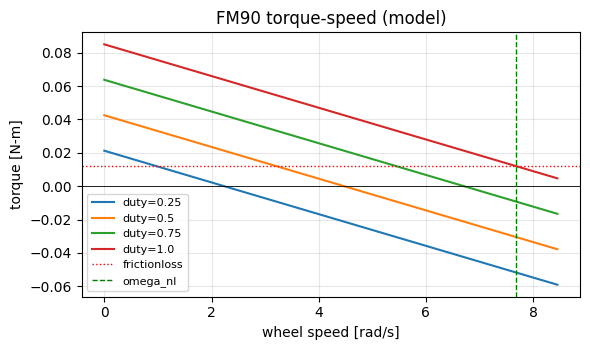

The full-duty line should cross frictionloss exactly at omega_nl.
Speed-limited, not torque-limited: wheels saturate at 0.26 m/s.


In [42]:
omegas = np.linspace(0, omega_nl_pred*1.1, 50)
fig, ax = plt.subplots(figsize=(6, 3.6))
for u in [0.25, 0.5, 0.75, 1.0]:
    ax.plot(omegas, tau_stall*u - b_m*omegas, label=f"duty={u}")
ax.axhline(0, color="k", lw=0.6)
ax.axhline(frictionloss, color="r", ls=":", lw=1, label="frictionloss")
ax.axvline(omega_nl_pred, color="g", ls="--", lw=1, label="omega_nl")
ax.set_xlabel("wheel speed [rad/s]"); ax.set_ylabel("torque [N-m]")
ax.set_title("FM90 torque-speed (model)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("The full-duty line should cross frictionloss exactly at omega_nl.")
print(f"Speed-limited, not torque-limited: wheels saturate at "
      f"{omega_nl_pred*r_wheel:.2f} m/s.")